<a href="https://colab.research.google.com/github/ignaciomorenobarria21-a11y/Machine_Learning/blob/main/Sesion_03_Regresion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎓 Fundamentos de Machine Learning

## Sesión 3: Ejemplo de Regresión

**Máster en Formación Permanente en Inteligencia Artificial para el Sector Financiero**  
Universidad Internacional de Valencia · Edición Octubre 2025/26

---

📅 **Fecha:** 15 de enero de 2026  
⏱️ **Duración:** ~100 minutos  
👨‍🏫 **Profesor:** Jaume Antolí Plaza

## 1. Introducción a la Regresión

### ¿Qué es la Regresión?

La **regresión** es una técnica de **aprendizaje supervisado** que predice un valor numérico continuo. A diferencia del clustering (que agrupa sin etiquetas) o la clasificación (que predice categorías), la regresión predice **cuánto**.

```
CLUSTERING                    CLASIFICACIÓN                 REGRESIÓN
─────────────────────────     ─────────────────────────     ─────────────────────────

"¿A qué grupo pertenece?"     "¿Qué categoría es?"          "¿Cuánto será?"

     ●  ●                          ▲ ▲                         Predicción: 0.0023
   ●  ●  ●                        ▲   ▲                        (retorno del +0.23%)
                                  
        ■  ■                       ● ●                         Predicción: -0.0015
      ■  ■  ■                     ●   ●                        (retorno del -0.15%)

  Sin etiquetas               Etiquetas: SUBE/BAJA          Etiqueta: valor numérico
```

### Aplicaciones en Finanzas

- **Predicción de retornos:** ¿Cuánto subirá o bajará el precio?
- **Estimación de volatilidad:** ¿Cuál será la volatilidad futura?
- **Valoración de activos:** ¿Cuál debería ser el precio justo?
- **Predicción de spreads:** ¿Cuál será el diferencial de tipos?

### Regresión Lineal: La Idea

La regresión lineal busca la **línea recta** (o hiperplano en múltiples dimensiones) que mejor se ajusta a los datos.

```
REGRESIÓN LINEAL SIMPLE (1 variable)
═════════════════════════════════════

    Retorno │                    ╱
    Futuro  │               ●  ╱
      ▲     │          ●    ╱  ●
      │     │       ●    ╱
      │     │    ●    ╱  ●
      │     │  ●   ╱
      │     │   ╱  ●
      │     │╱  ●
      └─────┴─────────────────────▶
                  RSI

    La línea minimiza la distancia a todos los puntos
    
    Fórmula: y = β₀ + β₁·x
    
    Donde:
    - y  = variable a predecir (Target_Return)
    - x  = variable predictora (RSI)
    - β₀ = intercepto (valor cuando x=0)
    - β₁ = pendiente (cuánto cambia y por cada unidad de x)
```

### Regresión Lineal Múltiple

Cuando usamos **varias variables** para predecir:

```
y = β₀ + β₁·RSI + β₂·Stochastic + β₃·CCI + β₄·ADX + ...
```

Cada coeficiente (β) nos dice **cuánto influye** esa variable en la predicción.

## 2. Configuración del Entorno

In [ ]:
# ============================================================
# CONFIGURACIÓN INICIAL
# Ejecuta esta celda antes de continuar (Shift + Enter)
# ============================================================

# Librerías básicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Librerías de Machine Learning
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 20)

# Ignorar warnings para una salida más limpia
import warnings
warnings.filterwarnings('ignore')

print("✅ Entorno configurado correctamente")

✅ Entorno configurado correctamente


## 3. Cargar el Dataset

Cargamos el mismo dataset que usamos en las sesiones anteriores: datos OHLCV del EUR/USD con indicadores técnicos.

In [ ]:
# ============================================================
# CARGA DE DATOS
# Dataset preparado en la Sesión 1 con indicadores técnicos
# ============================================================

# Cargar el dataset directamente desde Google Drive
url = 'https://drive.google.com/uc?id=13vNdqTBl4xZurr1jbcoVHCy9PinJosiL'
df = pd.read_csv(url, index_col=0, parse_dates=True)

print(f"Dataset cargado: {len(df):,} filas")
print(f"Período: {df.index[0].strftime('%Y-%m-%d')} a {df.index[-1].strftime('%Y-%m-%d')}")
print(f"Columnas totales: {len(df.columns)}")
df.head()

Dataset cargado: 2,489 filas
Período: 2010-05-25 a 2019-12-30
Columnas totales: 501


,Open,High,Low,Close,RSI_2,STOCH_2,WILLR_2,CCI_2,ADX_2,RSI_3,...,WILLR_99,CCI_99,ADX_99,RSI_100,STOCH_100,WILLR_100,CCI_100,ADX_100,Target_Return,Target_Direccion
Date,,,,,,,,,,,,,,,,,,,,,
2010-05-25,1.23684,1.23715,1.21747,1.23423,24.421350,41.330435,-57.244898,-12631.780092,58.297675,33.900535,...,-91.817137,-2434.608816,7.508539,27.285877,11.662837,-91.817137,-2415.491160,5.800495,-0.013466,0
2010-05-26,1.23454,1.23870,1.21651,1.21761,8.540825,18.673390,-95.042812,-30614.995315,55.630696,18.773705,...,-98.637557,-2373.603625,7.537198,26.645143,6.291037,-98.637557,-2357.164021,5.842580,0.015128,1
2010-05-27,1.21776,1.23936,1.21498,1.23603,62.538188,44.684518,-13.658737,-27969.102260,58.252217,53.366665,...,-91.078464,-2322.459890,7.568027,28.524123,6.155614,-91.078464,-2306.098927,5.886673,-0.007330,0
2010-05-28,1.23585,1.24518,1.22614,1.22697,39.561528,43.666813,-60.298013,-62192.874981,43.837486,40.607390,...,-94.796454,-2278.999465,7.587006,28.165683,5.162508,-94.796454,-2260.232794,5.919011,0.002812,1
2010-05-31,1.22748,1.23335,1.22568,1.23042,52.775417,50.116981,-75.692308,-55713.249821,31.356454,47.743744,...,-93.380663,-2233.290788,7.606547,28.511223,6.914806,-93.380663,-2215.977269,5.951770,-0.006250,0


### Nuestro Objetivo: Predecir el Retorno Futuro

En la Sesión 1 creamos la columna `Target_Return`, que contiene el **cambio porcentual de la siguiente vela**. Este es el valor que queremos predecir.

Estadísticas de Target_Return:
Media:     -0.000026
Std:       0.005471
Mínimo:    -0.025352
Máximo:    0.030669


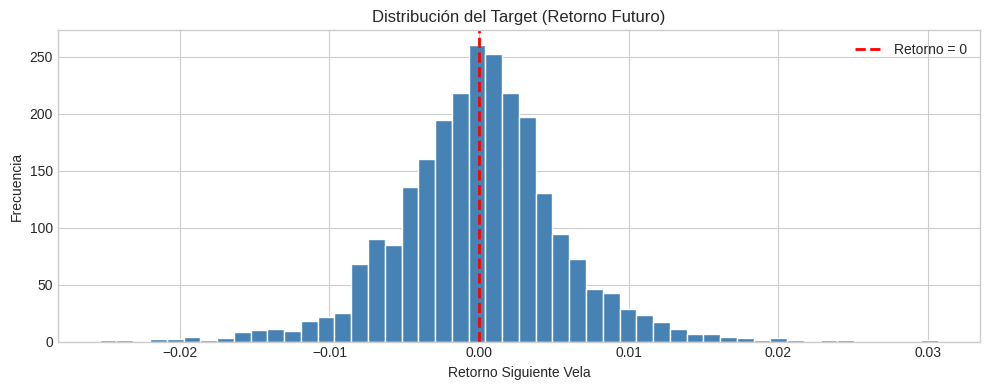

In [ ]:
# ============================================================
# EXPLORAR EL TARGET
# ============================================================

print("Estadísticas de Target_Return:")
print("=" * 40)
print(f"Media:     {df['Target_Return'].mean():.6f}")
print(f"Std:       {df['Target_Return'].std():.6f}")
print(f"Mínimo:    {df['Target_Return'].min():.6f}")
print(f"Máximo:    {df['Target_Return'].max():.6f}")
print("=" * 40)

# Visualizar distribución
fig, ax = plt.subplots(figsize=(10, 4))
df['Target_Return'].hist(bins=50, ax=ax, color='steelblue', edgecolor='white')
ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Retorno = 0')
ax.set_xlabel('Retorno Siguiente Vela')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución del Target (Retorno Futuro)')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Selección de Variables por Correlación

Tenemos **cientos de indicadores técnicos** en nuestro dataset (5 indicadores × ~100 periodos). Usar todos sería computacionalmente costoso y propenso a sobreajuste.

### Indicadores Direccionales vs No Direccionales

Antes de seleccionar, debemos entender qué indicadores tienen sentido para predecir **dirección**:

```
INDICADORES DIRECCIONALES              INDICADORES NO DIRECCIONALES
═══════════════════════════            ════════════════════════════

RSI, Stochastic, Williams %R, CCI      ADX

Valores altos → tendencia alcista      Valores altos → tendencia FUERTE
Valores bajos → tendencia bajista      (pero puede ser alcista O bajista)

✅ Útiles para predecir retorno        ❌ No predicen dirección
```

Por tanto, **excluiremos ADX** de nuestro análisis de regresión.

### Estrategia: Mejor Periodo por Indicador

Para cada indicador direccional, tenemos versiones con diferentes periodos (2, 3, 4, ... 100). ¿Cuál usar?

Calcularemos la **correlación con el target para cada periodo** y seleccionaremos el mejor.

In [ ]:
# ============================================================
# INDICADORES DIRECCIONALES Y SUS PERIODOS
# ============================================================

# Lista de indicadores direccionales (excluimos ADX)
indicadores_direccionales = ['RSI', 'STOCH', 'WILLR', 'CCI']

# Rango de periodos disponibles
periodos = range(2, 101)  # Del 2 al 100

print("Indicadores direccionales a analizar:")
print("=" * 40)
for ind in indicadores_direccionales:
    print(f"  • {ind}")
print("=" * 40)
print(f"\nPeriodos disponibles: {min(periodos)} a {max(periodos)}")
print(f"Total combinaciones por indicador: {len(list(periodos))}")

Indicadores direccionales a analizar:
  • RSI
  • STOCH
  • WILLR
  • CCI

Periodos disponibles: 2 a 100
Total combinaciones por indicador: 99


In [ ]:
# ============================================================
# CALCULAR CORRELACIÓN POR PERIODO PARA CADA INDICADOR
# ============================================================

# Diccionario para guardar correlaciones: {indicador: {periodo: correlación}}
correlaciones_por_periodo = {}

for indicador in indicadores_direccionales:
    correlaciones_por_periodo[indicador] = {}

    for periodo in periodos:
        col_name = f"{indicador}_{periodo}"

        # Verificar que la columna existe
        if col_name in df.columns:
            corr = df[col_name].corr(df['Target_Return'])
            correlaciones_por_periodo[indicador][periodo] = corr

print("✅ Correlaciones calculadas para todos los indicadores y periodos")

✅ Correlaciones calculadas para todos los indicadores y periodos


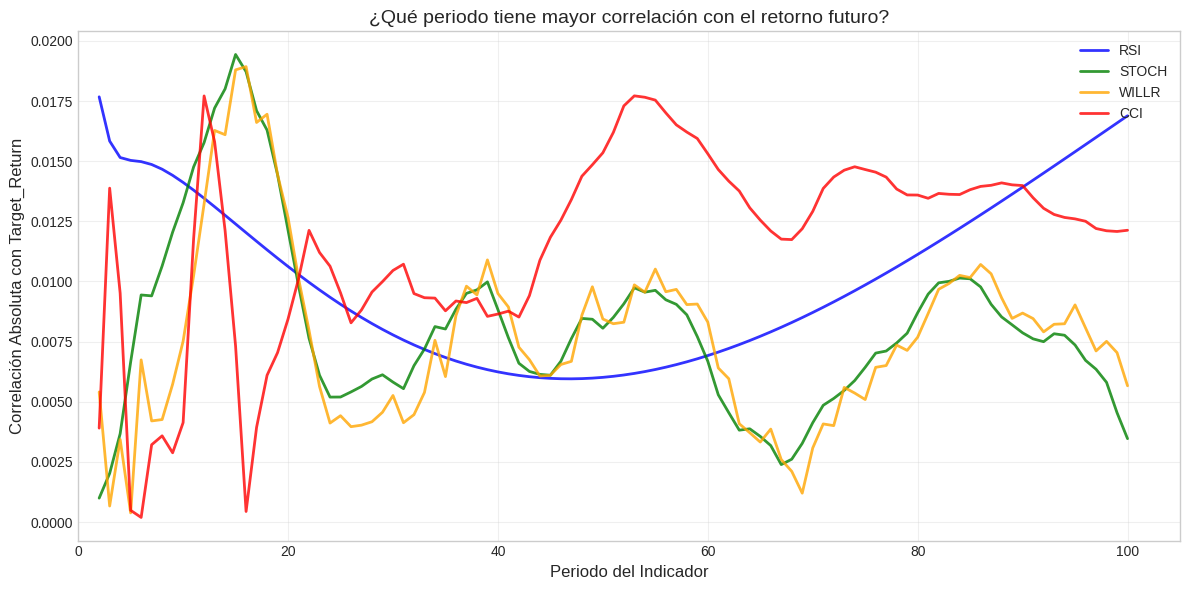

In [ ]:
# ============================================================
# GRÁFICO: CORRELACIÓN VS PERIODO PARA CADA INDICADOR
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

colores = {'RSI': 'blue', 'STOCH': 'green', 'WILLR': 'orange', 'CCI': 'red'}

for indicador in indicadores_direccionales:
    periodos_list = list(correlaciones_por_periodo[indicador].keys())
    corrs_abs = [abs(correlaciones_por_periodo[indicador][p]) for p in periodos_list]

    ax.plot(periodos_list, corrs_abs, label=indicador,
            color=colores[indicador], linewidth=2, alpha=0.8)

ax.set_xlabel('Periodo del Indicador', fontsize=12)
ax.set_ylabel('Correlación Absoluta con Target_Return', fontsize=12)
ax.set_title('¿Qué periodo tiene mayor correlación con el retorno futuro?', fontsize=14)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 105)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# SELECCIONAR EL MEJOR PERIODO DE CADA INDICADOR
# ============================================================

mejores_features = []

print("Mejor periodo para cada indicador (mayor correlación absoluta):")
print("=" * 60)

for indicador in indicadores_direccionales:
    # Encontrar el periodo con mayor correlación en valor absoluto
    mejor_periodo = max(correlaciones_por_periodo[indicador].keys(),
                        key=lambda p: abs(correlaciones_por_periodo[indicador][p]))

    mejor_corr = correlaciones_por_periodo[indicador][mejor_periodo]
    col_name = f"{indicador}_{mejor_periodo}"
    mejores_features.append(col_name)

    print(f"  {indicador:8} → Periodo {mejor_periodo:3}  (correlación: {mejor_corr:+.4f})")

print("=" * 60)
print(f"\nFeatures seleccionadas: {mejores_features}")

Mejor periodo para cada indicador (mayor correlación absoluta):
  RSI      → Periodo   2  (correlación: -0.0177)
  STOCH    → Periodo  15  (correlación: -0.0194)
  WILLR    → Periodo  16  (correlación: -0.0189)
  CCI      → Periodo  53  (correlación: +0.0177)

Features seleccionadas: ['RSI_2', 'STOCH_15', 'WILLR_16', 'CCI_53']


## 5. Preparar los Datos

Ahora preparamos nuestras matrices de features (X) y target (y) usando las 4 features seleccionadas.

**Nota importante:** A diferencia del clustering con K-Means, para regresión lineal **no necesitamos escalar** los datos. Los coeficientes se ajustan automáticamente a la escala de cada variable, y así son más fáciles de interpretar.

In [ ]:
# ============================================================
# PREPARAR X (FEATURES) E Y (TARGET)
# ============================================================

# Crear matriz de features con las mejores seleccionadas
X = df[mejores_features].copy()

# Crear vector target
y = df['Target_Return'].copy()

# Verificar dimensiones
print(f"Dimensiones de X: {X.shape}")
print(f"Dimensiones de y: {y.shape}")
print(f"\nFeatures utilizadas:")
for f in mejores_features:
    print(f"  • {f}")

# Vista previa
print("\nVista previa de X:")
X.head()

Dimensiones de X: (2489, 4)
Dimensiones de y: (2489,)

Features utilizadas:
  • RSI_2
  • STOCH_15
  • WILLR_16
  • CCI_53

Vista previa de X:


,RSI_2,STOCH_15,WILLR_16,CCI_53
Date,,,,
2010-05-25,24.421350,25.762708,-81.366227,-2350.183769
2010-05-26,8.540825,15.251200,-96.501212,-2238.406818
2010-05-27,62.538188,15.807777,-77.089261,-2152.437384
2010-05-28,39.561528,13.257456,-86.637159,-2087.926964
2010-05-31,52.775417,20.278595,-83.001370,-2034.694671


## 6. Entrenar el Modelo de Regresión Lineal

Usaremos `LinearRegression` de scikit-learn. El proceso es muy sencillo:

```
FLUJO DE ENTRENAMIENTO
══════════════════════

    ┌─────────┐      ┌─────────────────┐      ┌─────────────────┐
    │  Datos  │  →   │   .fit(X, y)    │  →   │ Modelo Entrenado│
    │  X, y   │      │  (aprender)     │      │  (coeficientes) │
    └─────────┘      └─────────────────┘      └─────────────────┘
```

In [ ]:
# ============================================================
# ENTRENAR MODELO DE REGRESIÓN LINEAL
# ============================================================

# Crear el modelo
modelo = LinearRegression()

# Entrenar (ajustar) el modelo con nuestros datos
modelo.fit(X, y)

print("✅ Modelo entrenado correctamente")
print("\n" + "=" * 60)
print("COEFICIENTES DEL MODELO")
print("=" * 60)
print(f"\nIntercepto (β₀): {modelo.intercept_:.8f}")
print("\nCoeficientes (β₁, β₂, ...):")
for feature, coef in zip(mejores_features, modelo.coef_):
    print(f"  {feature:15} → {coef:+.10f}")
print("=" * 60)

✅ Modelo entrenado correctamente

COEFICIENTES DEL MODELO

Intercepto (β₀): 0.00133751

Coeficientes (β₁, β₂, ...):
  RSI_2           → -0.0000048438
  STOCH_15        → -0.0000100126
  WILLR_16        → +0.0000085975
  CCI_53          → +0.0000000255


### Interpretación de los Coeficientes

Cada coeficiente nos dice **cuánto cambia la predicción** cuando esa variable aumenta en 1 unidad (manteniendo las demás constantes).

Por ejemplo, si el coeficiente del RSI es +0.00001:
- Cuando el RSI sube 1 punto, la predicción de retorno sube 0.00001 (0.001%)
- Cuando el RSI sube 10 puntos, la predicción sube 0.0001 (0.01%)

## 7. Hacer Predicciones

Una vez entrenado, usamos `.predict()` para obtener las predicciones del modelo.

In [ ]:
# ============================================================
# GENERAR PREDICCIONES
# ============================================================

# Predecir con el modelo entrenado
y_pred = modelo.predict(X)

# Añadir predicciones al dataframe
df['Prediccion_Retorno'] = y_pred

# Comparar predicción vs real
print("Comparación: Predicción vs Real (primeras 10 filas)")
print("=" * 50)
comparacion = df[['Target_Return', 'Prediccion_Retorno']].head(10)
comparacion.columns = ['Real', 'Predicción']
print(comparacion.to_string())
print("=" * 50)

Comparación: Predicción vs Real (primeras 10 filas)
                Real  Predicción
Date                            
2010-05-25 -0.013466    0.000202
2010-05-26  0.015128    0.000257
2010-05-27 -0.007330    0.000159
2010-05-28  0.002812    0.000215
2010-05-31 -0.006250    0.000113
2010-06-01  0.001652    0.000257
2010-06-02 -0.007038    0.000190
2010-06-03 -0.016248    0.000261
2010-06-04 -0.003544    0.000307
2010-06-07  0.004194    0.000413


## 8. Métricas de Evaluación

¿Cómo sabemos si nuestro modelo es bueno? Usamos **métricas de error**:

```
MÉTRICAS DE REGRESIÓN
═════════════════════

MAE (Mean Absolute Error)
─────────────────────────
Promedio del error absoluto.
"En promedio, ¿cuánto me equivoco?"

MAE = promedio( |real - predicción| )


MSE (Mean Squared Error)
─────────────────────────
Promedio del error al cuadrado.
Penaliza más los errores grandes.

MSE = promedio( (real - predicción)² )


RMSE (Root Mean Squared Error)
───────────────────────────────
Raíz cuadrada del MSE.
Está en las mismas unidades que el target.

RMSE = √MSE


R² (Coeficiente de Determinación)
──────────────────────────────────
¿Qué porcentaje de la variabilidad explica el modelo?
Va de 0 (no explica nada) a 1 (explica todo).
Puede ser negativo si el modelo es peor que la media.
```

In [ ]:
# ============================================================
# CALCULAR MÉTRICAS DE EVALUACIÓN
# ============================================================

# Calcular métricas
mae = mean_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y, y_pred)

print("=" * 50)
print("MÉTRICAS DEL MODELO")
print("=" * 50)
print(f"\nMAE  (Error Absoluto Medio):     {mae:.6f}")
print(f"MSE  (Error Cuadrático Medio):   {mse:.10f}")
print(f"RMSE (Raíz del MSE):             {rmse:.6f}")
print(f"R²   (Coef. Determinación):      {r2:.4f}")
print("\n" + "=" * 50)

# Interpretar R²
print(f"\nInterpretación del R²:")
print(f"El modelo explica el {r2*100:.2f}% de la variabilidad del retorno.")
if r2 < 0.01:
    print("→ Este valor es muy bajo, lo cual es NORMAL en mercados financieros.")
    print("→ Los mercados son muy difíciles de predecir.")

MÉTRICAS DEL MODELO

MAE  (Error Absoluto Medio):     0.004047
MSE  (Error Cuadrático Medio):   0.0000298913
RMSE (Raíz del MSE):             0.005467
R²   (Coef. Determinación):      0.0009


Interpretación del R²:
El modelo explica el 0.09% de la variabilidad del retorno.
→ Este valor es muy bajo, lo cual es NORMAL en mercados financieros.
→ Los mercados son muy difíciles de predecir.


## 9. Visualización: Predicción vs Real

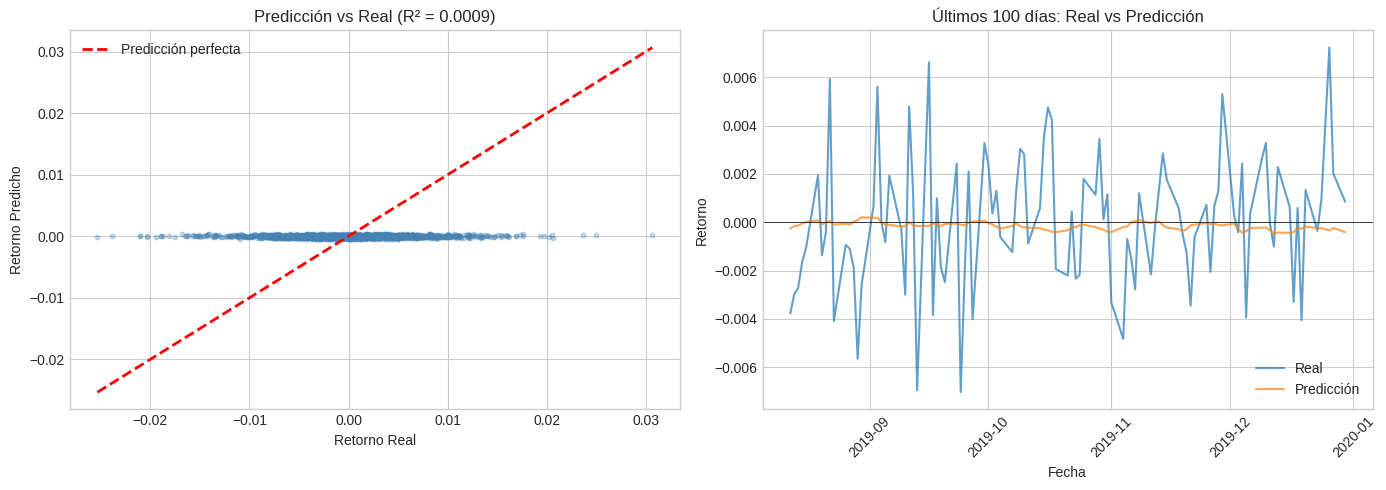

In [ ]:
# ============================================================
# GRÁFICO: PREDICCIÓN VS REAL
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Scatter plot
ax1 = axes[0]
ax1.scatter(y, y_pred, alpha=0.3, s=10, color='steelblue')
ax1.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', linewidth=2, label='Predicción perfecta')
ax1.set_xlabel('Retorno Real')
ax1.set_ylabel('Retorno Predicho')
ax1.set_title(f'Predicción vs Real (R² = {r2:.4f})')
ax1.legend()

# Gráfico 2: Serie temporal (últimos 100 días)
ax2 = axes[1]
ultimos_100 = df.tail(100)
ax2.plot(ultimos_100.index, ultimos_100['Target_Return'], label='Real', alpha=0.7)
ax2.plot(ultimos_100.index, ultimos_100['Prediccion_Retorno'], label='Predicción', alpha=0.7)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax2.set_xlabel('Fecha')
ax2.set_ylabel('Retorno')
ax2.set_title('Últimos 100 días: Real vs Predicción')
ax2.legend()
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 10. Aplicación: Sistema de Trading Simple

Vamos a convertir nuestras predicciones en un **sistema de trading**:

```
REGLAS DEL SISTEMA
══════════════════

Si Predicción > 0  →  🟢 COMPRAR (LONG)
Si Predicción < 0  →  🔴 VENDER (SHORT)
Si Predicción = 0  →  ⚪ FUERA DEL MERCADO
```

Calculamos el retorno del sistema y lo comparamos con mantener el EUR/USD (Buy & Hold).

In [ ]:
# ============================================================
# CREAR SISTEMA DE TRADING BASADO EN PREDICCIONES
# ============================================================

# Generar señales: +1 (long), -1 (short), 0 (fuera)
df['Señal'] = np.where(df['Prediccion_Retorno'] > 0, 1,
                       np.where(df['Prediccion_Retorno'] < 0, -1, 0))

# Calcular retorno del sistema
# Si estamos LONG, ganamos el retorno; si SHORT, ganamos el inverso
df['Retorno_Sistema'] = df['Señal'] * df['Target_Return']

# Calcular retorno acumulado (equity)
df['Equity_Sistema'] = (1 + df['Retorno_Sistema']).cumprod()
df['Equity_BuyHold'] = (1 + df['Target_Return']).cumprod()

# Mostrar resumen de señales
print("Distribución de señales:")
print("=" * 40)
print(f"🟢 LONG (comprar):    {(df['Señal'] == 1).sum():,} días")
print(f"🔴 SHORT (vender):    {(df['Señal'] == -1).sum():,} días")
print(f"⚪ FUERA:             {(df['Señal'] == 0).sum():,} días")
print("=" * 40)

Distribución de señales:
🟢 LONG (comprar):    1,105 días
🔴 SHORT (vender):    1,384 días
⚪ FUERA:             0 días


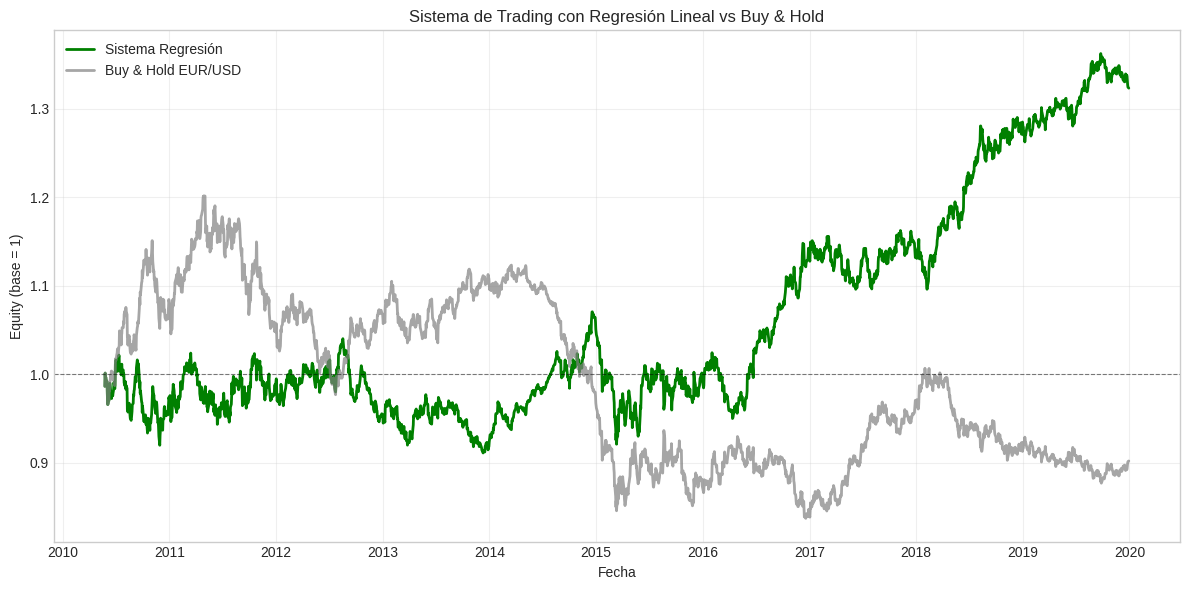

In [ ]:
# ============================================================
# GRÁFICO: EQUITY CURVE DEL SISTEMA
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(df.index, df['Equity_Sistema'], label='Sistema Regresión', linewidth=2, color='green')
ax.plot(df.index, df['Equity_BuyHold'], label='Buy & Hold EUR/USD', linewidth=2, color='gray', alpha=0.7)
ax.axhline(y=1, color='black', linestyle='--', linewidth=0.8, alpha=0.5)

ax.set_xlabel('Fecha')
ax.set_ylabel('Equity (base = 1)')
ax.set_title('Sistema de Trading con Regresión Lineal vs Buy & Hold')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# ESTADÍSTICAS DEL SISTEMA
# ============================================================

# Calcular estadísticas
retorno_sistema = df['Equity_Sistema'].iloc[-1] - 1
retorno_buyhold = df['Equity_BuyHold'].iloc[-1] - 1
dias_totales = len(df)
dias_long = (df['Señal'] == 1).sum()
dias_short = (df['Señal'] == -1).sum()
retorno_medio_diario = df['Retorno_Sistema'].mean()

# Aciertos direccionales
df['Acierto'] = (df['Señal'] * df['Target_Return']) > 0
pct_aciertos = df['Acierto'].mean() * 100

print("=" * 55)
print("ESTADÍSTICAS DEL SISTEMA DE REGRESIÓN")
print("=" * 55)
print(f"\n📊 RENDIMIENTO")
print(f"   Retorno Sistema:      {retorno_sistema*100:+.2f}%")
print(f"   Retorno Buy & Hold:   {retorno_buyhold*100:+.2f}%")
print(f"   Diferencia:           {(retorno_sistema-retorno_buyhold)*100:+.2f}%")
print(f"\n📅 POSICIONAMIENTO")
print(f"   Días totales:         {dias_totales:,}")
print(f"   Días en LONG:         {dias_long:,} ({dias_long/dias_totales*100:.1f}%)")
print(f"   Días en SHORT:        {dias_short:,} ({dias_short/dias_totales*100:.1f}%)")
print(f"\n🎯 PRECISIÓN")
print(f"   Aciertos dirección:   {pct_aciertos:.1f}%")
print(f"   Retorno medio diario: {retorno_medio_diario:.6f}")
print("=" * 55)

ESTADÍSTICAS DEL SISTEMA DE REGRESIÓN

📊 RENDIMIENTO
   Retorno Sistema:      +43.11%
   Retorno Buy & Hold:   -9.77%
   Diferencia:           +52.88%

📅 POSICIONAMIENTO
   Días totales:         2,489
   Días en LONG:         1,038 (41.7%)
   Días en SHORT:        1,316 (52.9%)

🎯 PRECISIÓN
   Aciertos dirección:   50.2%
   Retorno medio diario: 0.000158


### ⚠️ Advertencia Importante

Este sistema es **puramente educativo**. Hemos cometido un error metodológico grave:

**Hemos entrenado y evaluado con los mismos datos.**

Esto significa que el modelo ha "visto" todos los datos y puede haber memorizado patrones que no se repetirán en el futuro. En las próximas sesiones aprenderemos:

- **Sesión 8:** Partición In-Sample / Out-of-Sample
- **Sesión 9:** Sobreoptimización y validación cruzada

Por ahora, el objetivo es entender **cómo funciona la regresión lineal**, no crear un sistema de trading rentable.

---

## Resumen de la Sesión

En esta sesión hemos aprendido:

✅ **Qué es la regresión:** predecir un valor numérico continuo

✅ **Regresión lineal:** encontrar la recta/hiperplano que mejor se ajusta

✅ **Indicadores direccionales vs no direccionales:** RSI, Stochastic, Williams %R y CCI predicen dirección; ADX no

✅ **Selección del mejor periodo:** analizar correlación vs periodo para elegir la versión óptima de cada indicador

✅ **No es necesario escalar** para regresión lineal simple (a diferencia de K-Means)

✅ **Métricas de evaluación:** MAE, MSE, RMSE y R²

✅ **Aplicación práctica:** convertir predicciones en señales de trading

### Próxima Sesión

En la **Sesión 4 (20 de enero)** veremos **Clasificación**, donde en lugar de predecir un valor numérico, predeciremos una categoría: ¿subirá o bajará el precio?